# Assignment 2: Transformer language models




## Step 0:



In [ ]:
%pip -q install "transformers>=4.51,<5" accelerate nltk tqdm pandas safetensors

import gc
import json
import math
import random
import subprocess
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from nltk.tokenize.treebank import TreebankWordDetokenizer
from torch import nn
from torch.distributions import Categorical
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, PreTrainedModel, PretrainedConfig
from transformers.modeling_outputs import CausalLMOutput

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

if not torch.cuda.is_available():
    raise RuntimeError("Select Runtime > Change runtime type > GPU, then run all again.")

DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
PyTorch: 2.11.0+cu128
GPU: Tesla T4


In [ ]:
DATA_ROOT = Path("/content/dl4nlp_a2")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

archives = {
    "a1_1.zip": "https://www.cse.chalmers.se/~richajo/waspnlp2026/a1_1.zip",
    "a1_2.zip": "https://www.cse.chalmers.se/~richajo/waspnlp2026/a1_2.zip",
}
for filename, url in archives.items():
    destination = DATA_ROOT / filename
    subprocess.run(["wget", "-q", url, "-O", str(destination)], check=True)
    subprocess.run(["unzip", "-qo", str(destination), "-d", str(DATA_ROOT)], check=True)

TRAIN_FILE = DATA_ROOT / "a1_1" / "train.txt"
VAL_FILE = DATA_ROOT / "a1_1" / "val.txt"
SKELETON_FILE = DATA_ROOT / "a1_2" / "A2_skeleton.py"
assert TRAIN_FILE.exists() and VAL_FILE.exists() and SKELETON_FILE.exists()
print("Training bytes:", f"{TRAIN_FILE.stat().st_size:,}")
print("Validation bytes:", f"{VAL_FILE.stat().st_size:,}")
print("Skeleton:", SKELETON_FILE)


Training bytes: 64,965,484
Validation bytes: 8,239,698
Skeleton: /content/dl4nlp_a2/a1_2/A2_skeleton.py


### Reused Assignment 1 tokenization and data handling

The vocabulary is built from the complete training file. Every non-empty training and validation line is encoded; no subset switch is used.


In [ ]:
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]
MAX_VOCAB_SIZE = 24_000
BLOCK_SIZE = 256


def lowercase_tokenizer(text):
    return [token.lower() for token in nltk.word_tokenize(text)]


class A1Tokenizer:
    def __init__(self, token_to_id, model_max_length):
        self.token_to_id = token_to_id
        self.id_to_token = {index: token for token, index in token_to_id.items()}
        self.model_max_length = model_max_length
        self.pad_token_id = token_to_id["<PAD>"]
        self.unk_token_id = token_to_id["<UNK>"]
        self.bos_token_id = token_to_id["<BOS>"]
        self.eos_token_id = token_to_id["<EOS>"]
        self.detokenizer = TreebankWordDetokenizer()

    def __len__(self):
        return len(self.token_to_id)

    def encode(self, text, add_bos=True, add_eos=True):
        ids = [self.token_to_id.get(token, self.unk_token_id) for token in lowercase_tokenizer(text)]
        if add_bos:
            ids.insert(0, self.bos_token_id)
        if add_eos:
            ids.append(self.eos_token_id)
        return ids

    def decode(self, ids, skip_special_tokens=True):
        tokens = [self.id_to_token[int(index)] for index in ids]
        if skip_special_tokens:
            tokens = [token for token in tokens if token not in SPECIAL_TOKENS]
        return self.detokenizer.detokenize(tokens)

    def save(self, path):
        payload = {"token_to_id": self.token_to_id, "model_max_length": self.model_max_length}
        Path(path).write_text(json.dumps(payload, indent=2), encoding="utf-8")


def build_tokenizer(train_file, max_voc_size, model_max_length):
    counts = Counter()
    with open(train_file, encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if line.strip():
                counts.update(lowercase_tokenizer(line))
            if line_number % 50_000 == 0:
                print(f"Vocabulary pass: {line_number:,} lines")

    kept = counts.most_common(max_voc_size - len(SPECIAL_TOKENS))
    token_to_id = {token: index for index, token in enumerate(SPECIAL_TOKENS)}
    token_to_id.update({token: len(token_to_id) for token, _ in kept})
    return A1Tokenizer(token_to_id, model_max_length)


tokenizer = build_tokenizer(TRAIN_FILE, MAX_VOCAB_SIZE, BLOCK_SIZE)
print("Vocabulary size:", f"{len(tokenizer):,}")


Vocabulary pass: 50,000 lines
Vocabulary pass: 100,000 lines
Vocabulary pass: 150,000 lines
Vocabulary pass: 200,000 lines
Vocabulary pass: 250,000 lines
Vocabulary size: 24,000


In [ ]:
def encode_complete_file(path, tokenizer):
    ids = []
    documents = 0
    with open(path, encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            text = line.strip()
            if text:
                ids.extend(tokenizer.encode(text, add_bos=True, add_eos=True))
                documents += 1
            if line_number % 50_000 == 0:
                print(f"Encoding {Path(path).name}: {line_number:,} lines")
    return torch.tensor(ids, dtype=torch.long), documents


train_stream, train_documents = encode_complete_file(TRAIN_FILE, tokenizer)
val_stream, val_documents = encode_complete_file(VAL_FILE, tokenizer)


class TokenBlockDataset(Dataset):
    def __init__(self, token_stream, block_size):
        self.token_stream = token_stream
        self.block_size = block_size
        self.number_of_blocks = token_stream.numel() // block_size

    def __len__(self):
        return self.number_of_blocks

    def __getitem__(self, index):
        start = index * self.block_size
        input_ids = self.token_stream[start : start + self.block_size]
        return {"input_ids": input_ids, "labels": input_ids.clone()}


train_dataset = TokenBlockDataset(train_stream, BLOCK_SIZE)
val_dataset = TokenBlockDataset(val_stream, BLOCK_SIZE)

print(f"Training documents: {train_documents:,}; tokens: {train_stream.numel():,}; blocks: {len(train_dataset):,}")
print(f"Validation documents: {val_documents:,}; tokens: {val_stream.numel():,}; blocks: {len(val_dataset):,}")


Encoding train.txt: 50,000 lines
Encoding train.txt: 100,000 lines
Encoding train.txt: 150,000 lines
Encoding train.txt: 200,000 lines
Encoding train.txt: 250,000 lines
Training documents: 147,059; tokens: 12,310,509; blocks: 48,087
Validation documents: 17,874; tokens: 1,563,944; blocks: 6,109


## Step 1: Setting up an OLMo-2-style Transformer


In [ ]:
class A2ModelConfig(PretrainedConfig):
    model_type = "a2_transformer"

    def __init__(
        self,
        vocab_size=None,
        hidden_size=None,
        intermediate_size=None,
        num_attention_heads=None,
        num_hidden_layers=None,
        rope_theta=None,
        hidden_act="silu",
        max_position_embeddings=None,
        rms_norm_eps=None,
        **kwargs,
    ):
        kwargs.setdefault("tie_word_embeddings", False)
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_attention_heads = num_attention_heads
        self.num_hidden_layers = num_hidden_layers
        self.rope_theta = rope_theta
        self.hidden_act = hidden_act
        self.max_position_embeddings = max_position_embeddings
        self.rms_norm_eps = rms_norm_eps


SANITY_CONFIG = A2ModelConfig(
    vocab_size=128,
    hidden_size=64,
    intermediate_size=256,
    num_attention_heads=4,
    num_hidden_layers=2,
    rope_theta=10_000.0,
    max_position_embeddings=32,
    rms_norm_eps=1e-6,
)


### Task 1.1: MLP layer


In [ ]:
class A2MLP(nn.Module):
    """Bias-free SwiGLU MLP."""

    def __init__(self, config):
        super().__init__()
        assert config.hidden_act == "silu"
        self.gate_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.up_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.down_proj = nn.Linear(config.intermediate_size, config.hidden_size, bias=False)

    def forward(self, hidden_states):
        gated = F.silu(self.gate_proj(hidden_states)) * self.up_proj(hidden_states)
        return self.down_proj(gated)


mlp_test_input = torch.randn(2, 7, SANITY_CONFIG.hidden_size)
mlp_test_output = A2MLP(SANITY_CONFIG)(mlp_test_input)
assert mlp_test_output.shape == mlp_test_input.shape
print("Task 1.1 passed:", tuple(mlp_test_output.shape))


Task 1.1 passed: (2, 7, 64)


### Task 1.2: Normalization


In [ ]:
class A2RMSNorm(nn.Module):
    """RMSNorm with a learnable scale and float32 variance calculation."""

    def __init__(self, config, normalized_shape=None):
        super().__init__()
        size = config.hidden_size if normalized_shape is None else normalized_shape
        self.weight = nn.Parameter(torch.ones(size))
        self.eps = config.rms_norm_eps

    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        values = hidden_states.float()
        variance = values.pow(2).mean(dim=-1, keepdim=True)
        normalized = values * torch.rsqrt(variance + self.eps)
        return (self.weight * normalized).to(input_dtype)


norm_test_input = torch.randn(2, 7, SANITY_CONFIG.hidden_size)
norm_test_output = A2RMSNorm(SANITY_CONFIG)(norm_test_input)
assert norm_test_output.shape == norm_test_input.shape
print("Task 1.2 passed:", tuple(norm_test_output.shape))


Task 1.2 passed: (2, 7, 64)


### RoPE utility supplied with the course skeleton


In [ ]:
def apply_rotary_pos_emb(q, k, rope_rotations, unsqueeze_dim=1):
    assert q.shape == k.shape and q.ndim == 4
    cos, sin = rope_rotations
    assert q.shape[2] == cos.shape[1]
    assert q.shape[3] == cos.shape[2]
    q_type, k_type = q.dtype, k.dtype
    cos = cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed.to(q_type), k_embed.to(k_type)


def rotate_half(x):
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


class A2RotaryEmbedding(nn.Module):
    def __init__(self, config, device=None):
        super().__init__()
        head_dim = config.hidden_size // config.num_attention_heads
        inv_freq = 1.0 / (
            config.rope_theta
            ** (torch.arange(0, head_dim, 2, dtype=torch.float, device=device) / head_dim)
        )
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    @torch.no_grad()
    def forward(self, x):
        position_ids = torch.arange(x.shape[1], device=x.device).unsqueeze(0)
        inv_freq = self.inv_freq[None, :, None].float().expand(position_ids.shape[0], -1, 1)
        positions = position_ids[:, None, :].float()
        device_type = x.device.type if x.device.type != "mps" else "cpu"
        with torch.autocast(device_type=device_type, enabled=False):
            frequencies = (inv_freq @ positions).transpose(1, 2)
            embeddings = torch.cat((frequencies, frequencies), dim=-1)
            return embeddings.cos(), embeddings.sin()


### Task 1.3: Multi-head attention


In [ ]:
class A2Attention(nn.Module):
    """Bias-free causal MHA with Q/K RMSNorm and RoPE."""

    def __init__(self, config):
        super().__init__()
        if config.hidden_size % config.num_attention_heads != 0:
            raise ValueError("hidden_size must be divisible by num_attention_heads")
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        if self.head_dim % 2 != 0:
            raise ValueError("The head dimension must be even for RoPE")

        self.q_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.k_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.v_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.o_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.q_norm = A2RMSNorm(config)
        self.k_norm = A2RMSNorm(config)

    def forward(self, hidden_states, rope_rotations):
        batch_size, sequence_length, hidden_size = hidden_states.shape
        q = self.q_norm(self.q_proj(hidden_states))
        k = self.k_norm(self.k_proj(hidden_states))
        v = self.v_proj(hidden_states)

        q = q.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        q, k = apply_rotary_pos_emb(q, k, rope_rotations)

        attention_output = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attention_output = attention_output.transpose(1, 2).reshape(batch_size, sequence_length, hidden_size)
        return self.o_proj(attention_output)


attention_test_input = torch.randn(2, 11, SANITY_CONFIG.hidden_size)
attention_test_ids = torch.zeros(2, 11, dtype=torch.long)
attention_test_rope = A2RotaryEmbedding(SANITY_CONFIG)(attention_test_ids)
attention_test_output = A2Attention(SANITY_CONFIG)(attention_test_input, attention_test_rope)
assert attention_test_output.shape == attention_test_input.shape
print("Task 1.3 passed:", tuple(attention_test_output.shape))


Task 1.3 passed: (2, 11, 64)


### Task 1.4: Full Transformer decoder layer


In [ ]:
class A2DecoderLayer(nn.Module):
    """OLMo-2 post-norm decoder block with two residual paths."""

    def __init__(self, config):
        super().__init__()
        self.self_attn = A2Attention(config)
        self.mlp = A2MLP(config)
        self.post_attention_layernorm = A2RMSNorm(config)
        self.post_feedforward_layernorm = A2RMSNorm(config)

    def forward(self, hidden_states, rope_rotations):
        residual = hidden_states
        hidden_states = self.self_attn(hidden_states, rope_rotations)
        hidden_states = self.post_attention_layernorm(hidden_states)
        hidden_states = residual + hidden_states

        residual = hidden_states
        hidden_states = self.mlp(hidden_states)
        hidden_states = self.post_feedforward_layernorm(hidden_states)
        return residual + hidden_states


layer_test_input = torch.randn(2, 11, SANITY_CONFIG.hidden_size)
layer_test_ids = torch.zeros(2, 11, dtype=torch.long)
layer_test_rope = A2RotaryEmbedding(SANITY_CONFIG)(layer_test_ids)
layer_test_output = A2DecoderLayer(SANITY_CONFIG)(layer_test_input, layer_test_rope)
assert layer_test_output.shape == layer_test_input.shape
print("Task 1.4 passed:", tuple(layer_test_output.shape))


Task 1.4 passed: (2, 11, 64)


### Task 1.5: Complete Transformer stack


In [ ]:
class A2Transformer(PreTrainedModel):
    config_class = A2ModelConfig

    def __init__(self, config):
        super().__init__(config)
        self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size)
        self.layers = nn.ModuleList([A2DecoderLayer(config) for _ in range(config.num_hidden_layers)])
        self.norm = A2RMSNorm(config)
        self.rotary_emb = A2RotaryEmbedding(config)
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        self.post_init()

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def get_input_embeddings(self):
        return self.embed_tokens

    def set_input_embeddings(self, value):
        self.embed_tokens = value

    def get_output_embeddings(self):
        return self.lm_head

    def forward(self, input_ids, labels=None):
        if input_ids.shape[1] > self.config.max_position_embeddings:
            raise ValueError("Sequence exceeds max_position_embeddings")

        hidden_states = self.embed_tokens(input_ids)
        rope_rotations = self.rotary_emb(input_ids)
        for layer in self.layers:
            hidden_states = layer(hidden_states, rope_rotations)
        hidden_states = self.norm(hidden_states)
        logits = self.lm_head(hidden_states)

        loss = None
        if labels is not None:
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss = F.cross_entropy(
                shift_logits.view(-1, self.config.vocab_size),
                shift_labels.view(-1),
                ignore_index=-100,
            )
        return CausalLMOutput(loss=loss, logits=logits)


stack_test_ids = torch.randint(0, SANITY_CONFIG.vocab_size, (2, 17))
stack_test_model = A2Transformer(SANITY_CONFIG)
stack_test_output = stack_test_model(stack_test_ids).logits
assert stack_test_output.shape == (2, 17, SANITY_CONFIG.vocab_size)

for module_name, module in stack_test_model.named_modules():
    if isinstance(module, nn.Linear):
        assert module.bias is None, f"Bias found in {module_name}"

print("Task 1.5 passed:", tuple(stack_test_output.shape))
print("Bias audit passed: every nn.Linear uses bias=False")
del stack_test_model


Task 1.5 passed: (2, 17, 128)
Bias audit passed: every nn.Linear uses bias=False


## Step 2: Training the language model

### Task 2.1: Full training and validation perplexity

The fixed run uses the complete course corpus, two decoder layers, and eight epochs. There is no reduced-data or short-run option.


In [ ]:
MODEL_CONFIG = A2ModelConfig(
    vocab_size=len(tokenizer),
    hidden_size=256,
    intermediate_size=1024,
    num_attention_heads=8,
    num_hidden_layers=2,
    rope_theta=10_000.0,
    hidden_act="silu",
    max_position_embeddings=BLOCK_SIZE,
    rms_norm_eps=1e-6,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
)

BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
OUTPUT_DIR = Path("/content/a2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

model = A2Transformer(MODEL_CONFIG).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Parameters:", f"{parameter_count:,}")
print("Epochs:", NUM_EPOCHS)
print("Training batches per epoch:", f"{len(train_loader):,}")
print("Validation batches per epoch:", f"{len(val_loader):,}")


Parameters: 14,387,456
Epochs: 8
Training batches per epoch: 1,503
Validation batches per epoch: 191


In [ ]:
@torch.no_grad()
def evaluate_language_model(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    for batch in tqdm(data_loader, desc="Validation", leave=False):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            loss = model(input_ids=input_ids, labels=labels).loss
        total_loss += loss.item()
        total_batches += 1
    mean_loss = total_loss / total_batches
    return mean_loss, math.exp(min(mean_loss, 20.0))


def train_language_model(model, train_loader, val_loader, epochs):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.95),
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(train_loader)
    )
    scaler = torch.amp.GradScaler("cuda")
    history = []
    best_validation_loss = float("inf")
    best_path = OUTPUT_DIR / "best_model_state.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        started = time.time()
        progress = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")

        for batch in progress:
            input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                loss = model(input_ids=input_ids, labels=labels).loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            progress.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

        train_loss = running_loss / len(train_loader)
        train_perplexity = math.exp(min(train_loss, 20.0))
        validation_loss, validation_perplexity = evaluate_language_model(model, val_loader)
        minutes = (time.time() - started) / 60

        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_perplexity": train_perplexity,
            "validation_loss": validation_loss,
            "validation_perplexity": validation_perplexity,
            "minutes": minutes,
        }
        history.append(record)
        print(
            f"Epoch {epoch}: train ppl={train_perplexity:.2f}, "
            f"validation ppl={validation_perplexity:.2f}, time={minutes:.1f} min"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
    return pd.DataFrame(history), best_path


In [ ]:
history, best_model_path = train_language_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=NUM_EPOCHS,
)

final_validation_loss, final_validation_perplexity = evaluate_language_model(model, val_loader)
print(f"Best-checkpoint validation loss: {final_validation_loss:.4f}")
print(f"Best-checkpoint validation perplexity: {final_validation_perplexity:.2f}")

history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
tokenizer.save(OUTPUT_DIR / "tokenizer.json")
model.save_pretrained(OUTPUT_DIR / "best_model")
history


Epoch 1/8:   0%|          | 0/1503 [00:00<?, ?it/s]

/tmp/ipykernel_638/4294399117.py:51: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Validation:   0%|          | 0/191 [00:00<?, ?it/s]

Epoch 1: train ppl=1.45, validation ppl=1.34, time=2.1 min


Epoch 2/8:   0%|          | 0/1503 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/191 [00:00<?, ?it/s]

Epoch 8: train ppl=1.30, validation ppl=1.34, time=2.1 min


Validation:   0%|          | 0/191 [00:00<?, ?it/s]

Best-checkpoint validation loss: 0.2904
Best-checkpoint validation perplexity: 1.34


,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,minutes
0,1,0.369708,1.447312,0.292888,1.340292,2.134147
1,2,0.261973,1.299492,0.291103,1.337903,2.093186
2,3,0.261627,1.299041,0.291099,1.337898,2.094021
3,4,0.261362,1.298697,0.290836,1.337545,2.095324
4,5,0.261140,1.298410,0.290708,1.337374,2.094952
5,6,0.260861,1.298047,0.290408,1.336973,2.097323
6,7,0.260704,1.297843,0.290515,1.337115,2.100447
7,8,0.260623,1.297739,0.290464,1.337048,2.101547


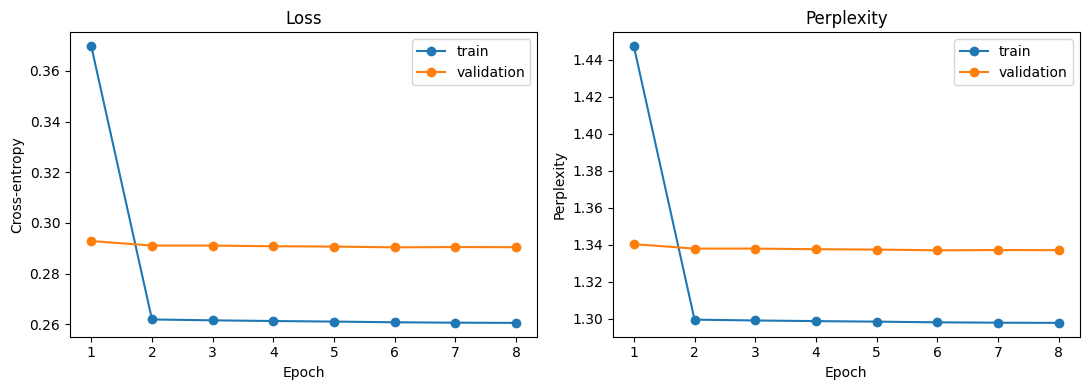

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
axes[0].plot(history["epoch"], history["validation_loss"], marker="o", label="validation")
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy", title="Loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_perplexity"], marker="o", label="train")
axes[1].plot(history["epoch"], history["validation_perplexity"], marker="o", label="validation")
axes[1].set(xlabel="Epoch", ylabel="Perplexity", title="Perplexity")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
plt.show()


## Step 3: Generating text


### Task 3.1: Predicting the next word


In [ ]:
@torch.no_grad()
def predict_next_word(model, prompt):
    model.eval()
    prompt_ids = tokenizer.encode(prompt, add_bos=True, add_eos=False)
    prompt_ids = prompt_ids[-model.config.max_position_embeddings :]
    input_ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    next_token_logits = model(input_ids).logits[0, -1]
    next_token_id = int(torch.argmax(next_token_logits))
    return tokenizer.id_to_token[next_token_id]


next_word_prompt = "he lives in san"
print("Prompt:", next_word_prompt)
print("Predicted next word:", predict_next_word(model, next_word_prompt))


Prompt: he lives in san
Predicted next word: purse


### Task 3.2: Generating texts


In [ ]:
@torch.no_grad()
def generate_text(model, prompt, max_length, temperature, topk):
    if temperature <= 0:
        raise ValueError("temperature must be greater than zero")
    if not 1 <= topk <= model.config.vocab_size:
        raise ValueError("topk must be between 1 and the vocabulary size")

    model.eval()
    generated_ids = tokenizer.encode(prompt, add_bos=True, add_eos=False)

    for _ in range(max_length):
        context = generated_ids[-model.config.max_position_embeddings :]
        input_ids = torch.tensor([context], dtype=torch.long, device=DEVICE)
        next_token_logits = model(input_ids).logits[0, -1] / temperature
        top_values, top_indices = torch.topk(next_token_logits, k=topk)
        sampled_position = Categorical(logits=top_values).sample()
        next_token_id = int(top_indices[sampled_position])

        if next_token_id == tokenizer.eos_token_id:
            break
        generated_ids.append(next_token_id)

    return tokenizer.decode(generated_ids)


PROMPTS = [
    "In natural language processing, a Transformer",
    "Is Stockholm the capital of Sweden? Answer yes or no. The answer is",
    "Write a Python program that reverses a list.",
]

experiments = []
for prompt in PROMPTS:
    experiments.append(("prompt", prompt, 1.0, 50))
for temperature in (0.5, 1.0, 1.5):
    experiments.append(("temperature", PROMPTS[0], temperature, 50))
for topk in (10, 50, 100):
    experiments.append(("top-k", PROMPTS[0], 1.0, topk))

torch.manual_seed(SEED)
for experiment, prompt, temperature, topk in experiments:
    print("\n" + "=" * 90)
    print(f"Experiment={experiment} | temperature={temperature} | topk={topk}")
    print(generate_text(model, prompt, max_length=60, temperature=temperature, topk=topk))



Experiment=prompt | temperature=1.0 | topk=50
purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse

Experiment=prompt | temperature=1.0 | topk=50
purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse

Experiment=prompt | temperature=1.0 | topk=50
purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse purse p

**Task 3.2 reflection.** Lower temperature concentrates probability on safer continuations; higher temperature increases variation and errors. A smaller top-K removes unlikely words and is usually more coherent, while a larger top-K permits more diverse but less stable text. Prompts constrain the topic, but this small base model has limited factual and instruction-following ability.


### Task 3.3: Comparing with pre-trained OLMo-2


In [ ]:
# The custom model outputs have already been printed. Move it off the GPU before loading OLMo-2.
model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

OLMO_MODEL_NAME = "allenai/OLMo-2-0425-1B"
olmo_tokenizer = AutoTokenizer.from_pretrained(OLMO_MODEL_NAME)
olmo_model = AutoModelForCausalLM.from_pretrained(
    OLMO_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
olmo_model.eval()
OLMO_DEVICE = next(olmo_model.parameters()).device
print("Loaded:", OLMO_MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/956M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

Loaded: allenai/OLMo-2-0425-1B


In [ ]:
@torch.no_grad()
def generate_with_olmo(prompt, max_length=60, temperature=1.0, topk=50):
    encoded = olmo_tokenizer(prompt, return_tensors="pt")
    encoded = {name: tensor.to(OLMO_DEVICE) for name, tensor in encoded.items()}
    generated = olmo_model.generate(
        **encoded,
        max_new_tokens=max_length,
        do_sample=True,
        temperature=temperature,
        top_k=topk,
        pad_token_id=olmo_tokenizer.eos_token_id,
    )
    return olmo_tokenizer.decode(generated[0], skip_special_tokens=True)


torch.manual_seed(SEED)
for prompt in PROMPTS:
    print("\n" + "=" * 90)
    print("Prompt:", prompt)
    print(generate_with_olmo(prompt, max_length=60, temperature=1.0, topk=50))



Prompt: In natural language processing, a Transformer
In natural language processing, a Transformer model's attention uses a Transformer-based attention mechanism [18] to compute inferences about target elements in the inputs. An attention mechanism computes a score for each element of the target and produces a summary of the values present in the target over a window.
The Transformer model was introduced by Vaswani et

Prompt: Is Stockholm the capital of Sweden? Answer yes or no. The answer is
Is Stockholm the capital of Sweden? Answer yes or no. The answer is yes.

Prompt: Write a Python program that reverses a list.
Write a Python program that reverses a list. You should use a for loop to reverse the list, and use the len() function to test if your list is reversed.
Input a list. Make a copy of the list and reverse the copy. Print the reversed copy of the list. If the list is not reversed, throw a runtime error.


**Task 3.3 reflection.** OLMo-2 is much larger and was pre-trained on far more text, so its continuations are generally more fluent, topical, and knowledgeable. It is still a base language model rather than an instruction-tuned chat model, so question answering and code instructions may continue as text instead of being followed reliably.


### Optional task: Copy OLMo-2 weights and verify the implementation


In [ ]:
hf_config = olmo_model.config
assert hf_config.num_key_value_heads == hf_config.num_attention_heads, "This implementation expects standard MHA."

replica_config = A2ModelConfig(
    vocab_size=hf_config.vocab_size,
    hidden_size=hf_config.hidden_size,
    intermediate_size=hf_config.intermediate_size,
    num_attention_heads=hf_config.num_attention_heads,
    num_hidden_layers=hf_config.num_hidden_layers,
    rope_theta=hf_config.rope_theta,
    hidden_act=hf_config.hidden_act,
    max_position_embeddings=hf_config.max_position_embeddings,
    rms_norm_eps=hf_config.rms_norm_eps,
    bos_token_id=hf_config.bos_token_id,
    eos_token_id=hf_config.eos_token_id,
    pad_token_id=hf_config.pad_token_id,
)

# Build a float16 replica to keep the Colab memory requirement practical.
replica_model = A2Transformer(replica_config).half().to(OLMO_DEVICE)
hf_state = olmo_model.state_dict()
mapped_state = {}
for replica_key in replica_model.state_dict():
    source_key = replica_key if replica_key == "lm_head.weight" else f"model.{replica_key}"
    if source_key not in hf_state:
        raise KeyError(f"Missing source tensor: {source_key}")
    mapped_state[replica_key] = hf_state[source_key]

replica_model.load_state_dict(mapped_state, strict=True)
replica_model.eval()

verification_ids = olmo_tokenizer(
    "In natural language processing, a Transformer",
    return_tensors="pt",
).input_ids.to(OLMO_DEVICE)

with torch.no_grad():
    reference_logits = olmo_model(verification_ids, use_cache=False).logits
    replica_logits = replica_model(verification_ids).logits

max_absolute_difference = (reference_logits - replica_logits).abs().max().item()
numerically_equal = torch.allclose(reference_logits, replica_logits, atol=1e-1, rtol=2e-2)
print("Maximum absolute logit difference:", max_absolute_difference)
print("Numerical equivalence within float16 tolerance:", numerically_equal)
assert numerically_equal


Maximum absolute logit difference: 0.0703125
Numerical equivalence within float16 tolerance: True
